<a href="https://colab.research.google.com/github/foultraengineer9/AI_Final_Project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English Word Complexity Classifier
This notebook implements a machine learning system (stacked ensemble with a deep learning + classical model) to classify English words into three CEFR difficulty tiers:

Tier 0 (Beginner): A1–A2
Tier 1 (Intermediate): B1–B2
Tier 2 (Advanced): C1–C2

## Improvements over pervious notebooks

*   *deprecated* **Semantic Space:** Contextual Sentence Transformer Embeddings (`all-MiniLM-L6-v2`).
*   **Psycholinguistic Norms:** Brysbaert Concreteness Ratings, Familiarity Ratings, and SUBTLEX-US Frequency.
*   **Linguistic Taxonomy:** Taxonomic depth and polysemy tracking via NLTK WordNet.
*   **Orthographic Metrics:** Consonant cluster density, character Shannon entropy, and academic affixes.
* **768D Transformer Space:** Migrated from MiniLM to the state-of-the-art `all-mpnet-base-v2` semantic encoder.

* **Expanded Feature Space (30D):** Added WordNet Hyponym counts, NLTK Lemmatization (derivation indicators), and Letter Diversity.

* **Label Smoothing (0.10):** Prevents overconfidence on boundary terms.

* **Triple-Stack Ensemble:** Blends Gradient Boosting (XGBoost), Bagging (Random Forest), and Representation Learning (Late Fusion MLP).

# Part 1: Initial Setup & Environment Config

In [ ]:
!pip install -q syllables xgboost scikit-learn tensorflow sentence-transformers nltk

import os
import re
import numpy as np
import pandas as pd
import nltk
import syllables
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sentence_transformers import SentenceTransformer

# Download NLTK requirements
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer

# Load high-capacity 768-dimensional Sentence Transformer
embedding_model = SentenceTransformer("all-mpnet-base-v2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 3.8 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Part 2: Feature Extraction Pipeline

This class incorporates psycholinguistic lookups and taxonomical WordNet queries into a single feature extraction state. This stateful class extracts traditional complexity features alongside advanced orthographic metrics, preserving the fitted scaler and cluster configurations across both training and inference.

In [ ]:
class WordComplexityFeaturePipeline:
    """
    Stateful complexity pipeline incorporating psycholinguistic norms,
    WordNet taxonomic depth/hyponyms, NLTK lemmatization, and 768D MPNet embeddings
    """
    def __init__(self, transformer_model, concreteness_df=None, n_clusters=6):
        self.transformer = transformer_model
        self.n_clusters = n_clusters
        self.frequency_dict = {}

        # Stateful modeling configurations
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.lemmatizer = WordNetLemmatizer()
        self.is_fitted = False

        # Pillar 1 Lookup Dictionaries
        self.concreteness_mean = {}
        self.concreteness_sd = {}
        self.percent_known = {}
        self.subtlex_freq = {}

        if concreteness_df is not None:
            self._load_psycholinguistic_norms(concreteness_df)

    def _load_psycholinguistic_norms(self, df):
        """Builds lookup tables for psycholinguistic norm parameters."""
        df_clean = df.dropna(subset=['Word']).copy()
        df_clean['Word_lower'] = df_clean['Word'].astype(str).str.lower()

        self.concreteness_mean = pd.Series(df_clean['Conc.M'].values, index=df_clean['Word_lower']).to_dict()
        self.concreteness_sd = pd.Series(df_clean['Conc.SD'].values, index=df_clean['Word_lower']).to_dict()
        self.percent_known = pd.Series(df_clean['Percent_known'].values, index=df_clean['Word_lower']).to_dict()
        self.subtlex_freq = pd.Series(df_clean['SUBTLEX'].values, index=df_clean['Word_lower']).to_dict()
        print(f"Psycholinguistic norms successfully mapped for {len(df_clean)} words.")

    def _calculate_vowel_ratio(self, word):
        word = str(word).lower()
        if not word:
            return 0.0
        vowels = sum(1 for char in word if char in 'aeiouy')
        return round(vowels / len(word), 2)

    def _calculate_char_entropy(self, word):
        """Calculates the Shannon Entropy of characters inside a word."""
        word = str(word).lower()
        if not word:
            return 0.0
        counts = {}
        for char in word:
            counts[char] = counts.get(char, 0) + 1
        entropy = 0.0
        length = len(word)
        for count in counts.values():
            p = count / length
            entropy -= p * np.log2(p)
        return round(entropy, 4)

    def _calculate_consonant_cluster_density(self, word):
        """Finds the maximum run of consecutive consonants (density check)."""
        word = str(word).lower()
        consonants = re.findall(r'[^aeiouy\W]+', word)
        if not consonants:
            return 0
        return max(len(c) for c in consonants)

    def _check_advanced_affixes(self, word):
        """Identifies complex suffixes or prefixes common in academic English."""
        word = str(word).lower()
        suffixes = ['characterization', 'ization', 'ability', 'tional', 'ative', 'istic', 'ology', 'ment', 'ship', 'ness', 'ity', 'ise', 'ize', 'ate', 'ify']
        prefixes = ['counter', 'pseudo', 'trans', 'mono', 'hyper', 'inter', 'retro', 'ultra', 'circum']

        has_suffix = 1 if any(word.endswith(s) for s in suffixes) else 0
        has_prefix = 1 if any(word.startswith(p) for p in prefixes) else 0
        return has_suffix, has_prefix

    def _extract_wordnet_features(self, word):
        """Pillar 2: Queries WordNet taxonomy depth, hyponym density, and definition (polysemy) density."""
        word_clean = str(word).lower()
        synsets = wn.synsets(word_clean)
        polysemy_count = len(synsets)
        if not synsets:
            return 0.0, 0.0, 0.0  # Default depth, polysemy, and hyponyms

        max_depth = max(s.max_depth() for s in synsets)
        hyponym_count = len(synsets[0].hyponyms())
        return float(polysemy_count), float(max_depth), float(hyponym_count)

    def fit(self, df):
        """Fits structural scaler and K-Means clusters from training data."""
        df_clean = df.dropna(subset=['headword']).copy()
        df_clean['headword_lower'] = df_clean['headword'].astype(str).str.lower()

        # Save training frequencies as fallback lookup
        self.frequency_dict = pd.Series(
            df_clean['frequency'].values,
            index=df_clean['headword_lower']
        ).to_dict()

        # Generate structural space
        raw_structs = []
        for _, row in df_clean.iterrows():
            struct_feat = self._extract_raw_structural(
                word=row['headword_lower'],
                tag=row.get('POS_tag', 'NN'),
                freq_val=row['frequency']
            )
            raw_structs.append(struct_feat)

        raw_structs_matrix = np.array(raw_structs)

        # Standardize and compute cluster states
        scaled_structs = self.scaler.fit_transform(raw_structs_matrix)
        self.kmeans.fit(scaled_structs)

        self.is_fitted = True
        print(f"Pipeline structural space fit on {len(df_clean)} samples.")

    def _extract_raw_structural(self, word, tag, freq_val):
        """Assembles structural, morphological, psycholinguistic, and semantic features."""
        word_clean = str(word).lower()
        length = len(word_clean)
        syll_count = syllables.estimate(word_clean)
        vowel_ratio = self._calculate_vowel_ratio(word_clean)

        # Base scaling calculations
        freq_scaled = np.log1p(freq_val)
        syll_per_char = syll_count / length if length > 0 else 0
        freq_syll_interaction = freq_scaled * syll_count

        # Advanced Orthographics
        char_entropy = self._calculate_char_entropy(word_clean)
        cluster_density = self._calculate_consonant_cluster_density(word_clean)
        has_suffix, has_prefix = self._check_advanced_affixes(word_clean)

        # Unique characters ratio (Orthographic diversity)
        letter_diversity = len(set(word_clean)) / length if length > 0 else 0

        # Part-Of-Speech Tag Map
        pos_vec = [0, 0, 0, 0, 0]  # JJ, RB, NN, VB, UNKNOWN
        if tag.startswith('JJ'):
            pos_vec[0] = 1
        elif tag.startswith('RB'):
            pos_vec[1] = 1
        elif tag.startswith('NN'):
            pos_vec[2] = 1
        elif tag.startswith('VB'):
            pos_vec[3] = 1
        else:
            pos_vec[4] = 1

        # Lemmatization Check (Checks if word is inflected/derived)
        lemma = self.lemmatizer.lemmatize(word_clean)
        is_derived = 1 if lemma != word_clean else 0

        # Pillar 1 Lookup (Concreteness & Familiarity)
        conc_mean = self.concreteness_mean.get(word_clean, 3.0)
        conc_sd = self.concreteness_sd.get(word_clean, 1.0)
        p_known = self.percent_known.get(word_clean, 0.90)
        subtlex_val = self.subtlex_freq.get(word_clean, 0.0)
        subtlex_scaled = np.log1p(subtlex_val)

        # Pillar 2 Lookup (WordNet Taxonomy, Polysemy, and Hyponyms)
        polysemy_count, tax_depth, hyponym_count = self._extract_wordnet_features(word_clean)

        return [
            length, syll_count, freq_scaled, vowel_ratio,
            pos_vec[0], pos_vec[1], pos_vec[2], pos_vec[3], pos_vec[4],
            syll_per_char, freq_syll_interaction,
            char_entropy, cluster_density, has_suffix, has_prefix,
            conc_mean, conc_sd, p_known, subtlex_scaled,
            polysemy_count, tax_depth, hyponym_count, is_derived, letter_diversity
        ]

    def transform_single_word(self, word, tag='NN'):
        """Computes structural, taxonomical, and semantic states dynamically."""
        word_lower = str(word).lower()
        freq_val = self.frequency_dict.get(word_lower, 0.0)
        raw_struct = self._extract_raw_structural(word_lower, tag, freq_val)

        if self.is_fitted:
            scaled_struct = self.scaler.transform([raw_struct])
            cluster_id = self.kmeans.predict(scaled_struct)[0]
            cluster_onehot = [0] * self.n_clusters
            cluster_onehot[cluster_id] = 1
            final_struct = raw_struct + cluster_onehot
        else:
            cluster_onehot = [0] * self.n_clusters
            final_struct = raw_struct + cluster_onehot

        # Encode semantics using the 768D Sentence Transformer encoder
        semantic_vector = self.transformer.encode(word_lower, convert_to_numpy=True)
        return semantic_vector, np.array(final_struct)

    def transform_dataframe(self, df):
        """Transforms a whole dataframe containing 'headword' columns."""
        semantic_list = []
        structural_list = []
        for _, row in df.iterrows():
            tag = row.get('POS_tag', 'NN')
            sem, struct = self.transform_single_word(row['headword'], tag)
            semantic_list.append(sem)
            structural_list.append(struct)
        return np.array(semantic_list), np.array(structural_list)

# Part 3: Data Loading & Preparation

In [ ]:
csv_path = '/content/processed_vocab.csv'

if os.path.exists(csv_path):
    print(f"Loading vocabulary from: {csv_path}")
    raw_df = pd.read_csv(csv_path)
else:
    print("Warning: Vocabulary CSV file not found. Building representative standalone subset...")
    mock_dataset = [
        ("the", 100000, "DT", 1), ("cat", 8000, "NN", 1), ("house", 7500, "NN", 1),
        ("and", 90000, "CC", 1), ("beautiful", 3500, "JJ", 2), ("quickly", 2100, "RB", 2),
        ("adventure", 1800, "NN", 3), ("explore", 1500, "VB", 3), ("hypothesis", 600, "NN", 4),
        ("exacerbate", 120, "VB", 5), ("metamorphosis", 80, "NN", 6), ("ephemeral", 45, "JJ", 6),
        ("dog", 7200, "NN", 1), ("run", 8900, "VB", 1), ("standard", 1900, "NN", 3),
        ("philanthropy", 95, "NN", 6), ("juxtaposition", 110, "NN", 6), ("ambiguous", 310, "JJ", 5)
    ] * 500
    raw_df = pd.DataFrame(mock_dataset, columns=['headword', 'frequency', 'POS_tag', 'CEFR_numeric'])

# Map numerical codes to CEFR broad categories
tier_mapping = {1: 0, 2: 0, 3: 1, 4: 1, 5: 2, 6: 2}
raw_df['tier'] = raw_df['CEFR_numeric'].map(tier_mapping)

print("Classification Category Balance:")
print(raw_df['tier'].value_counts())

Loading vocabulary from: /content/processed_vocab.csv
Classification Category Balance:
tier
1    5045
0    2418
2    1981
Name: count, dtype: int64


# Part 4: Concreteness Integration & Pipeline Balance Setup

Integrates the Brysbaert Concreteness database (loading TSV/CSV) and configures the damped class weights.

In [ ]:
concreteness_path = '/content/concreteness.csv'

if not os.path.exists(concreteness_path):
    print("Concreteness file not found. Generating mock concreteness database...")
    mock_words = raw_df['headword'].unique()
    mock_conc = []
    for w in mock_words:
        mock_conc.append({
            "Word": w,
            "Bigram": 0,
            "Conc.M": 3.5 if len(w) < 6 else 1.8,
            "Conc.SD": 1.1,
            "Unknown": 0,
            "Total": 30,
            "Percent_known": 0.98 if len(w) < 6 else 0.85,
            "SUBTLEX": 5000 if len(w) < 6 else 50
        })
    conc_df = pd.DataFrame(mock_conc)
    conc_df.to_csv(concreteness_path, index=False)

# Load Concreteness File
try:
    concreteness_df = pd.read_csv(concreteness_path)
    if 'Conc.M' not in concreteness_df.columns:
        concreteness_df = pd.read_csv(concreteness_path, sep='\t')
except Exception as e:
    print(f"Error reading concreteness file: {e}.")
    concreteness_df = None

# Fit stateful pipeline with 768D Transformer
pipeline = WordComplexityFeaturePipeline(
    transformer_model=embedding_model,
    concreteness_df=concreteness_df,
    n_clusters=6
)
pipeline.fit(raw_df)

# Retrieve raw matrices
X_sem_raw, X_struct_raw = pipeline.transform_dataframe(raw_df)
y = raw_df['tier'].values

# Split data
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_sem_train_raw, X_sem_test_raw = X_sem_raw[train_idx], X_sem_raw[test_idx]
X_struct_train_raw, X_struct_test_raw = X_struct_raw[train_idx], X_struct_raw[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize structural properties securely
struct_scaler = StandardScaler()
X_struct_train_scaled = struct_scaler.fit_transform(X_struct_train_raw)
X_struct_test_scaled = struct_scaler.transform(X_struct_test_raw)

# Combine inputs
X_train_combined = np.hstack((X_sem_train_raw, X_struct_train_scaled))
X_test_combined = np.hstack((X_sem_test_raw, X_struct_test_scaled))

# Compute sample weights for XGBoost
xgb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

class_weights_vals = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
# Dampen class weights to protect majority-class recall (Intermediate)
damped_weights_vals = 0.6 * class_weights_vals + 0.4 * 1.0
mlp_class_weights = dict(enumerate(damped_weights_vals))

# Prepare one-hot targets for the Neural Network to use Label Smoothing
y_train_onehot = to_categorical(y_train, num_classes=3)
y_test_onehot = to_categorical(y_test, num_classes=3)

print("Advanced features engineered and one-hot labels formatted.")

Psycholinguistic norms successfully mapped for 39953 words.
Pipeline structural space fit on 9444 samples.
Advanced features engineered and one-hot labels formatted.


# Part 5: Supervised Learning (XGBoost)

In [ ]:
print("Fitting Supervised XGBoost Classifier with 768D Embeddings...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    tree_method='hist'
)
xgb_clf.fit(X_train_combined, y_train, sample_weight=xgb_sample_weights)

y_pred_xgb = xgb_clf.predict(X_test_combined)
print("\n--- TUNED XGBOOST PERFORMANCE ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Beginner', 'Intermediate', 'Advanced']))


# Introduce Random Forest to diversify the bagging ensemble
print("Fitting Supervised Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_combined, y_train)

y_pred_rf = rf_clf.predict(X_test_combined)
print("\n--- TUNED RANDOM FOREST PERFORMANCE ---")
print(classification_report(y_test, y_pred_rf, target_names=['Beginner', 'Intermediate', 'Advanced']))

Fitting Supervised XGBoost Classifier with 768D Embeddings...

--- TUNED XGBOOST PERFORMANCE ---
              precision    recall  f1-score   support

    Beginner       0.64      0.73      0.68       484
Intermediate       0.75      0.62      0.67      1009
    Advanced       0.61      0.78      0.68       396

    accuracy                           0.68      1889
   macro avg       0.67      0.71      0.68      1889
weighted avg       0.69      0.68      0.68      1889

Fitting Supervised Random Forest Classifier...

--- TUNED RANDOM FOREST PERFORMANCE ---
              precision    recall  f1-score   support

    Beginner       0.67      0.52      0.59       484
Intermediate       0.67      0.79      0.72      1009
    Advanced       0.70      0.58      0.64       396

    accuracy                           0.68      1889
   macro avg       0.68      0.63      0.65      1889
weighted avg       0.68      0.68      0.67      1889



# Part 6: Deep Learning Classifier

Late Fusion MLP mapping Multi-Pillar inputs.

In [ ]:
from tensorflow.keras import regularizers

# Regularization penalty
l2_penalty = regularizers.l2(5e-5)

# Branch inputs: configure structural size and 768D semantic size
semantic_input = layers.Input(shape=(X_sem_train_raw.shape[1],), name="mpnet_semantic_stream")
structural_input = layers.Input(shape=(X_struct_train_scaled.shape[1],), name="structural_stream")

# Semantic processing layers (Deeper capacity for 768D inputs)
sem_layer = layers.Dense(256, activation='relu', kernel_regularizer=l2_penalty)(semantic_input)
sem_layer = layers.BatchNormalization()(sem_layer)
sem_layer = layers.Dropout(0.40)(sem_layer)
sem_layer = layers.Dense(128, activation='relu', kernel_regularizer=l2_penalty)(sem_layer)
sem_layer = layers.Dropout(0.30)(sem_layer)
sem_layer = layers.Dense(64, activation='relu', kernel_regularizer=l2_penalty)(sem_layer)
sem_layer = layers.Dropout(0.20)(sem_layer)

# Structural processing layers
struct_layer = layers.Dense(32, activation='relu', kernel_regularizer=l2_penalty)(structural_input)
struct_layer = layers.BatchNormalization()(struct_layer)
struct_layer = layers.Dropout(0.25)(struct_layer)
struct_layer = layers.Dense(16, activation='relu', kernel_regularizer=l2_penalty)(struct_layer)
struct_layer = layers.Dropout(0.15)(struct_layer)

# Merge streams
merged_path = layers.concatenate([sem_layer, struct_layer])

# Classifier layers
merged_dense = layers.Dense(32, activation='relu', kernel_regularizer=l2_penalty)(merged_path)
merged_dense = layers.Dropout(0.25)(merged_dense)
outputs = layers.Dense(3, activation='softmax', name="classifier_output")(merged_dense)

# Model configuration
late_fusion_model = models.Model(inputs=[semantic_input, structural_input], outputs=outputs)

# Using Adam optimizer with a learning rate of 3e-4
opt = tf.keras.optimizers.Adam(learning_rate=3e-4)

# Use Categorical Crossentropy with 10% Label Smoothing
late_fusion_model.compile(
    optimizer=opt,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10),
    metrics=['accuracy']
)

# Overfitting safeguards
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-5
)

print("\nFitting 768D Late Fusion Deep Neural Network...")
late_fusion_model.fit(
    x=[X_sem_train_raw, X_struct_train_scaled],
    y=y_train_onehot, # Fits on one-hot targets for label smoothing
    validation_data=([X_sem_test_raw, X_struct_test_scaled], y_test_onehot),
    epochs=100,
    batch_size=64,
    class_weight=mlp_class_weights,
    callbacks=[early_stop, lr_decay],
    verbose=1
)

y_pred_mlp_probs = late_fusion_model.predict([X_sem_test_raw, X_struct_test_scaled])
y_pred_mlp = np.argmax(y_pred_mlp_probs, axis=-1)

print("\n--- 768D LATE FUSION NEURAL NETWORK PERFORMANCE ---")
print(classification_report(y_test, y_pred_mlp, target_names=['Beginner', 'Intermediate', 'Advanced']))


Fitting 768D Late Fusion Deep Neural Network...
Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3746 - loss: 1.2001 - val_accuracy: 0.4346 - val_loss: 1.1141 - learning_rate: 3.0000e-04
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5255 - loss: 1.0071 - val_accuracy: 0.5776 - val_loss: 1.0403 - learning_rate: 3.0000e-04
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5824 - loss: 0.9432 - val_accuracy: 0.6416 - val_loss: 0.9748 - learning_rate: 3.0000e-04
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6026 - loss: 0.9149 - val_accuracy: 0.6585 - val_loss: 0.9206 - learning_rate: 3.0000e-04
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6275 - loss: 0.8917 - val_accuracy: 0.6596 - val_loss: 0.8819 - learning_rate: 3.0000e-04
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6508 - loss: 0.8682 - val_accuracy: 0.6580 - val_loss: 0.8567 - learning_rate: 3.0000e-04
Epoch 7/

# Part 7: Ensembling

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- TRIPLE-STACK SOFT ENSEMBLE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Beginner       0.66      0.73      0.70       484
Intermediate       0.75      0.66      0.70      1009
    Advanced       0.63      0.75      0.69       396

    accuracy                           0.70      1889
   macro avg       0.68      0.71      0.69      1889
weighted avg       0.70      0.70      0.70      1889



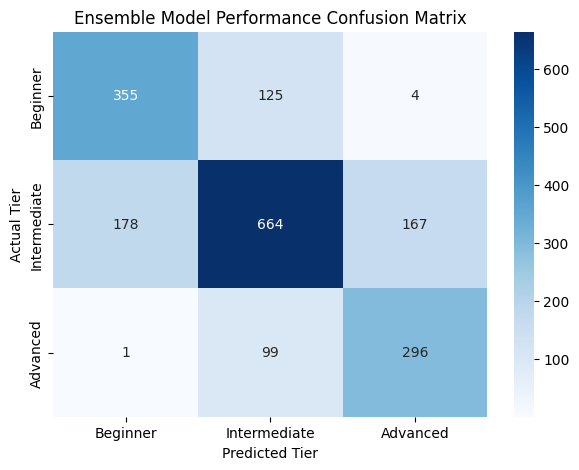

In [ ]:
prob_xgb = xgb_clf.predict_proba(X_test_combined)
prob_rf = rf_clf.predict_proba(X_test_combined)
prob_mlp = late_fusion_model.predict([X_sem_test_raw, X_struct_test_scaled])

# Blended distribution (45% XGBoost, 15% Random Forest, 40% Neural Network)
ensemble_probs = (0.45 * prob_xgb) + (0.15 * prob_rf) + (0.40 * prob_mlp)
y_pred_ensemble = np.argmax(ensemble_probs, axis=-1)

print("\n--- TRIPLE-STACK SOFT ENSEMBLE CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_ensemble, target_names=['Beginner', 'Intermediate', 'Advanced']))

# Generate and plot confusion matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Beginner', 'Intermediate', 'Advanced'],
            yticklabels=['Beginner', 'Intermediate', 'Advanced'])
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.title('Ensemble Model Performance Confusion Matrix')
plt.show()

# Part 8: Inference

In [ ]:
synonym_database = {
    "exacerbate": "worsen",
    "hypothesis": "guess",
    "metamorphosis": "change",
    "philanthropy": "charity",
    "ephemeral": "short-lived",
    "ambiguous": "unclear",
    "beautiful": "pretty"
}

def analyze_passage(passage, target_comfort_level=1):
    """
    Parses a string text passage, tags word tokens, extracts features
    using the fitted pipeline state, and highlights difficult content terms.
    """
    words = re.findall(r'\b\w+\b', passage)
    tagged_tokens = nltk.pos_tag(words)
    results = []

    for word, tag in tagged_tokens:
        word_lower = word.lower()
        is_content = tag.startswith(('NN', 'VB', 'JJ', 'RB'))

        # 1. Pipeline transformations using fitted instances
        single_sem, single_struct = pipeline.transform_single_word(word_lower, tag)
        scaled_single_struct = struct_scaler.transform([single_struct])

        # 2. Probability extraction from all streams
        xgb_prob = xgb_clf.predict_proba(np.hstack((single_sem.reshape(1, -1), scaled_single_struct)))
        rf_prob = rf_clf.predict_proba(np.hstack((single_sem.reshape(1, -1), scaled_single_struct)))
        mlp_prob = late_fusion_model.predict([single_sem.reshape(1, -1), scaled_single_struct], verbose=0)

        # Soft voting
        fused_prob = (0.45 * xgb_prob) + (0.15 * rf_prob) + (0.40 * mlp_prob)
        predicted_tier = int(np.argmax(fused_prob, axis=-1)[0])

        # Flagging logic
        is_difficult = is_content and (predicted_tier > target_comfort_level)
        status = "CHALLENGING" if is_difficult else "OK"
        suggestion = synonym_database.get(word_lower, None) if is_difficult else None

        results.append({
            "word": word,
            "pos": tag,
            "predicted_tier": predicted_tier,
            "status": status,
            "suggestion": suggestion
        })

    return results


if __name__ == "__main__":
    sample_text = "Dinosaurs are a diverse group of reptiles of the clade Dinosauria. They first appeared during the Triassic period and became the dominant terrestrial vertebrates."

    print("\nExecuting live analysis for target Tier 1 (Intermediate Comfort Level)...")
    results = analyze_passage(sample_text, target_comfort_level=1)

    for item in results:
        if item['status'] == "CHALLENGING":
            print(f"[!] '{item['word']}' (Predicted Tier: {item['predicted_tier']})")
            if item['suggestion']:
                print(f"    ↳ Simplification suggestion: '{item['suggestion']}'")
        else:
            print(f"    '{item['word']}'")


Executing live analysis for target Tier 1 (Intermediate Comfort Level)...
[!] 'Dinosaurs' (Predicted Tier: 2)
    'are'
    'a'
    'diverse'
    'group'
    'of'
[!] 'reptiles' (Predicted Tier: 2)
    'of'
    'the'
[!] 'clade' (Predicted Tier: 2)
[!] 'Dinosauria' (Predicted Tier: 2)
    'They'
    'first'
[!] 'appeared' (Predicted Tier: 2)
    'during'
    'the'
[!] 'Triassic' (Predicted Tier: 2)
    'period'
    'and'
[!] 'became' (Predicted Tier: 2)
    'the'
[!] 'dominant' (Predicted Tier: 2)
[!] 'terrestrial' (Predicted Tier: 2)
[!] 'vertebrates' (Predicted Tier: 2)


# **Part 9: Part 8 Improved**

This module dynamically queries WordNet for POS-aligned synonym candidates, grades their complexity using the trained XGBoost, Random Forest, and MLP ensemble, and ranks them to select the most pedagogically appropriate simplification.

In [ ]:
def pluralize_noun(word):
    """Applies standard spelling rules to pluralize a singular noun."""
    word = str(word).lower()
    if word.endswith(('s', 'x', 'z', 'ch', 'sh')):
        return word + 'es'
    elif word.endswith('y') and not word[-2] in 'aeiou':
        return word[:-1] + 'ies'
    elif word.endswith('f') and word != 'cliff':
        return word[:-1] + 'ves'
    elif word.endswith('fe'):
        return word[:-2] + 'ves'
    else:
        return word + 's'


def match_inflection(suggested_word, original_word, pos_tag):
    """
    Conjugates or inflects the suggested word to match the grammatical
    cues (plurality, tense) of the original word.
    """
    s_word = str(suggested_word).lower()

    # 1. Plural Nouns
    if pos_tag in ['NNS', 'NNPS']:
        return pluralize_noun(s_word)

    # 2. Verb Tenses and Gerunds
    if pos_tag == 'VBG':  # Present Participle (e.g., running)
        if s_word.endswith('e') and not s_word.endswith('ee'):
            return s_word[:-1] + 'ing'
        return s_word + 'ing'

    elif pos_tag in ['VBD', 'VBN']:  # Past Tense / Past Participle
        if s_word.endswith('e'):
            return s_word + 'd'
        elif s_word.endswith('y') and not s_word[-2] in 'aeiou':
            return s_word[:-1] + 'ied'
        return s_word + 'ed'

    elif pos_tag == 'VBZ':  # 3rd Person Singular Present (e.g., runs)
        return pluralize_noun(s_word)  # Shares spelling rules with plural nouns

    return s_word


def get_wordnet_candidates(word, pos_tag):
    """
    Queries WordNet using the base lemma, and recursively traverses up the
    taxonomic tree (up to 5 levels) while mapping candidate words to their
    taxonomic distance (steps climbed).
    """
    word_clean = str(word).lower()

    wn_pos = None
    pos_char = 'n'
    if pos_tag.startswith('JJ'):
        wn_pos = wn.ADJ
        pos_char = 'a'
    elif pos_tag.startswith('RB'):
        wn_pos = wn.ADV
        pos_char = 'r'
    elif pos_tag.startswith('VB'):
        wn_pos = wn.VERB
        pos_char = 'v'
    elif pos_tag.startswith('NN'):
        wn_pos = wn.NOUN
        pos_char = 'n'

    if not wn_pos:
        return {}

    # Lemmatize the target word first so it matches WordNet's singular base indices
    orig_lemma = pipeline.lemmatizer.lemmatize(word_clean, pos_char)

    # Dual Synset Lookup: Fall back to raw lowercase word if the lemma yields no synsets
    synsets = wn.synsets(orig_lemma, pos=wn_pos)
    if not synsets and orig_lemma != word_clean:
        synsets = wn.synsets(word_clean, pos=wn_pos)

    candidates = {} # Maps candidate_word -> distance (int)

    for syn in synsets:
        # 1. Grab synonyms (lemmas in the same synset - distance 0)
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ').lower()
            cand_lemma = pipeline.lemmatizer.lemmatize(candidate, pos_char)
            # Apply Lemma Guard to prevent suggesting different inflections of the same root
            if cand_lemma != orig_lemma and ' ' not in candidate:
                candidates[candidate] = 0

        # 2. Grab hypernyms (climbing up the taxonomic tree, mapping distance 1 to 5)
        current_syns = syn.hypernyms()
        for distance in range(1, 6):
            next_syns = []
            for h in current_syns:
                for lemma in h.lemmas():
                    candidate = lemma.name().replace('_', ' ').lower()
                    cand_lemma = pipeline.lemmatizer.lemmatize(candidate, pos_char)
                    if cand_lemma != orig_lemma and ' ' not in candidate:
                        # Retain the shortest distance if a candidate is reached via multiple paths
                        if candidate not in candidates:
                            candidates[candidate] = distance
                next_syns.extend(h.hypernyms())
            current_syns = next_syns

    return candidates


def find_dynamic_simplification(word, pos_tag, target_comfort_level, original_tier):
    """
    Evaluates candidate synonyms/hypernyms, scores them via our ensemble,
    and returns the best match using a step-down complexity fallback and taxonomic distance sorting.
    """
    candidates_dict = get_wordnet_candidates(word, pos_tag)
    if not candidates_dict:
        return None

    graded_candidates = []

    for candidate, distance in candidates_dict.items():
        single_sem, single_struct = pipeline.transform_single_word(candidate, pos_tag)
        scaled_single_struct = struct_scaler.transform([single_struct])
        combined_features = np.hstack((single_sem.reshape(1, -1), scaled_single_struct))

        xgb_prob = xgb_clf.predict_proba(combined_features)
        rf_prob = rf_clf.predict_proba(combined_features)
        mlp_prob = late_fusion_model.predict([single_sem.reshape(1, -1), scaled_single_struct], verbose=0)

        fused_prob = (0.45 * xgb_prob) + (0.15 * rf_prob) + (0.40 * mlp_prob)
        predicted_tier = int(np.argmax(fused_prob, axis=-1)[0])

        frequency = pipeline.frequency_dict.get(candidate, 0.0)
        word_length = len(candidate)

        graded_candidates.append({
            "word": candidate,
            "tier": predicted_tier,
            "distance": distance,
            "frequency": frequency,
            "length": word_length
        })

    # Standard Filter: Keep candidates within the user's exact comfort level
    viable_candidates = [c for c in graded_candidates if c['tier'] <= target_comfort_level]

    # Step-Down Fallback (Number 2): If no candidate reaches the target, look for any candidate strictly simpler than the original word
    if not viable_candidates:
        viable_candidates = [c for c in graded_candidates if c['tier'] < original_tier]

    if not viable_candidates:
        return None

    # Sort: 1) Lowest tier, 2) Closest taxonomic distance, 3) Highest frequency, 4) Shortest length
    viable_candidates.sort(key=lambda x: (x['tier'], x['distance'], -x['frequency'], x['length']))

    return viable_candidates[0]['word']


def analyze_passage(passage, target_comfort_level=1):
    """
    Analyzes a text passage, flags complex terms, and suggests grammatically
    re-inflected, simpler alternatives while protecting Proper Noun named entities from corruption.
    """
    words = re.findall(r'\b\w+\b', passage)
    tagged_tokens = nltk.pos_tag(words)
    results = []

    for word, tag in tagged_tokens:
        word_lower = word.lower()
        is_content = tag.startswith(('NN', 'VB', 'JJ', 'RB'))

        # Proper Noun Protection: Identify NNP and NNPS tags to prevent entity corruption
        is_proper_noun = tag in ['NNP', 'NNPS']

        # Extract features for the target word
        single_sem, single_struct = pipeline.transform_single_word(word_lower, tag)
        scaled_single_struct = struct_scaler.transform([single_struct])
        combined_features = np.hstack((single_sem.reshape(1, -1), scaled_single_struct))

        xgb_prob = xgb_clf.predict_proba(combined_features)
        rf_prob = rf_clf.predict_proba(combined_features)
        mlp_prob = late_fusion_model.predict([single_sem.reshape(1, -1), scaled_single_struct], verbose=0)

        fused_prob = (0.45 * xgb_prob) + (0.15 * rf_prob) + (0.40 * mlp_prob)
        predicted_tier = int(np.argmax(fused_prob, axis=-1)[0])

        # Proper nouns are safely skipped from being flagged as challenging
        is_difficult = is_content and not is_proper_noun and (predicted_tier > target_comfort_level)
        status = "CHALLENGING" if is_difficult else "OK"

        suggestion = None
        if is_difficult:
            # Pass predicted_tier to enable step-down complexity logic
            best_base_candidate = find_dynamic_simplification(word_lower, tag, target_comfort_level, predicted_tier)
            if best_base_candidate:
                # Conjugate/inflect the suggestion to match sentence grammar
                suggestion = match_inflection(best_base_candidate, word, tag)

        results.append({
            "word": word,
            "pos": tag,
            "predicted_tier": predicted_tier,
            "status": status,
            "suggestion": suggestion
        })

    return results


In [ ]:
if __name__ == "__main__":
    sample_text = "Dinosaurs are a diverse group of reptiles of the clade Dinosauria."

    print("\nExecuting live analysis for target Tier 1 (Intermediate Comfort Level)...")
    results = analyze_passage(sample_text, target_comfort_level=1)

    for item in results:
        if item['status'] == "CHALLENGING":
            print(f"[!] '{item['word']}' (Predicted Tier: {item['predicted_tier']})")
            if item['suggestion']:
                print(f"    ↳ Dynamic Simplification suggested: '{item['suggestion']}'")
            else:
                print(f"    ↳ No simpler POS-aligned alternative found.")
        else:
            print(f"    '{item['word']}'")


Executing live analysis for target Tier 1 (Intermediate Comfort Level)...
[!] 'Dinosaurs' (Predicted Tier: 2)
    ↳ No simpler POS-aligned alternative found.
    'are'
    'a'
    'diverse'
    'group'
    'of'
[!] 'reptiles' (Predicted Tier: 2)
    ↳ Dynamic Simplification suggested: 'animals'
    'of'
    'the'
[!] 'clade' (Predicted Tier: 2)
    ↳ Dynamic Simplification suggested: 'group'
    'Dinosauria'
